## TS7: Filtrado digital lineal de ECG

Usando el archivo `ecg.mat` que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas a continuación, diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (alta frecuencia).
- Ruido muscular (alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (baja frecuencia).

**Ayuda:** los detalles de cómo acceder a `ecg.mat` se encuentran en `lectura_sigs.py`.

### Archivo `ECG.mat` (variables)

- `ecg_lead`: registro de ECG muestreado a $f_s = 1\,\text{kHz}$ durante una prueba de esfuerzo.
- `qrs_pattern1`: complejo de ondas QRS normal.
- `heartbeat_pattern1`: latido normal.
- `heartbeat_pattern2`: latido de origen ventricular.
- `qrs_detections`: vector con las localizaciones (en número de muestras) donde ocurren los latidos.

### Se pide

**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** utilice los resultados del ancho de banda estimado del ECG en la Tarea Semanal 5. Tome como referencia las morfologías promedio (`heartbeat_pattern1`, `heartbeat_pattern2`) para evaluar cualitativamente la efectividad de los filtros diseñados.

**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe al menos dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-McClellan-Remez. Todos implementados en `scipy.signal`.

**d)** Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.

### Bonus 💎

Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada, y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
from pytc2.sistemas_lineales import plot_plantilla


In [2]:
# Frecuencia 
fs = 1000 # Hz

# ww es para el WorN
ww = np.concat([np.logspace(start = -2, stop = 0.1, num = 500),
                np.linspace(start = 1.26, stop = 35, num = 200),
                np.logspace(start = 1.55, stop = 1.65, num = 300),
                np.linspace(start = 46, stop = fs//2, num = 50)])

# Plantilla de diseño del filtro 
wp1 = 1 # Hz
wp2 = 35 # Hz --> 30 es aprox el ancho de banda que nos dio en la TS5
ws1 = .1 # Hz \
ws2 = 45 # Hz
gpass = 1 # dB
gstop = 40 # dB 

wp = (wp1, wp2) # Comienzo y fin de la banda de paso
ws = (ws1, ws2) # Comienzo y fin de la banda de stop

# Funciones de aproximacion 
# ftype = 'butter'
# ftype = 'cheby1'
# ftype = 'cheby2'
# ftype = 'cauer'

In [3]:
#%% Funciones de aproximacion 
sos_f_butter = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'butter', output = 'sos', fs = fs) # Es de maxima planicidad en ambas bandas 
sos_f_cauer = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cauer', output = 'sos', fs = fs)
sos_f_cheby2 = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cheby2', output = 'sos', fs = fs)

# b_coeff,a_coeff = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cauer', output = 'ba', fs = fs) # Ahora voy al mundo digital (Transferencia tipo Cauer)
# Es equiripple en la banda de paso y en la banda de stop 

# b_coeff,a_coeff = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cheby1', output = 'ba', fs = fs) # Ahora voy al mundo digital (Transferencia tipo Cheby 1) 
# Es equiripple en la banda de paso y max planicidad (parecido a max planicidad) en banda de stop 

# b_coeff,a_coeff = sig.iirdesign(wp, ws, gpass, gstop, analog = False, ftype = 'cheby2', output = 'ba', fs = fs) # Ahora voy al mundo digital (Transferencia tipo Cheby 2) 
# Es equiripple en la banda de stop y max planicidad (parecido a max planicidad) en banda de paso

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2313163827.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.plot(omega_butter, 20*np.log10(abs(resp_freq_butter)), label="FIR")


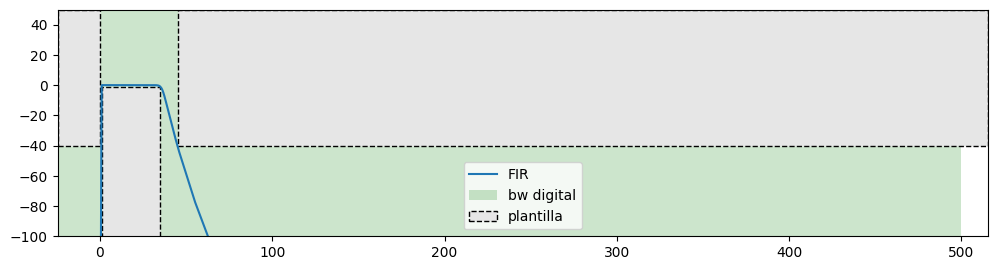

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2313163827.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2313163827.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2313163827.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


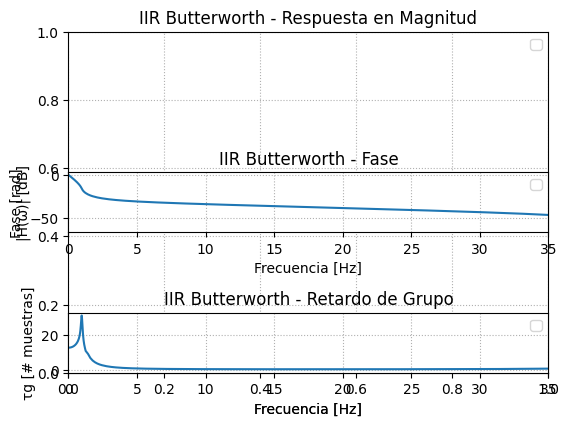

In [4]:
#%% BUTTERWORTH
taps_butter = sos_f_butter.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega_butter, resp_freq_butter = sig.freqz_sos(sos_f_butter, worN = ww, fs = fs)
phase_butter = np.unwrap(np.angle(resp_freq_butter))
gd_butter = -np.diff(phase_butter) / np.diff(ww)
gd_butter = np.append(gd_butter[0], gd_butter)

# GRAFICOS

# MODULO
plt.figure(figsize=(12,10))

plt.subplot(3,1,1)
plt.plot(omega_butter, 20*np.log10(abs(resp_freq_butter)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('IIR Butterworth - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
# plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(omega_butter, phase_butter)
plt.title('IIR Butterworth - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(ww, gd_butter)
plt.title('IIR Butterworth - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

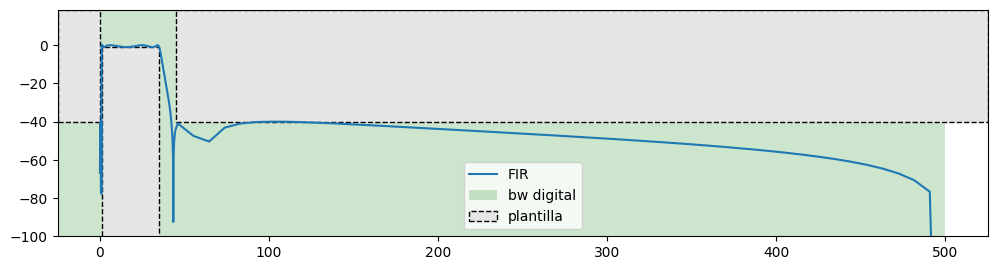

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\831673460.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\831673460.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\831673460.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


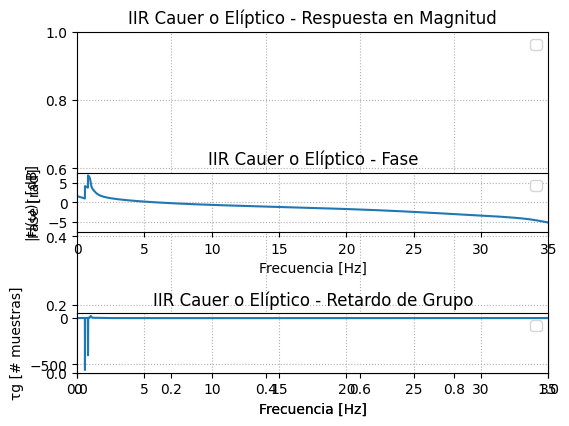

In [5]:
#%% CAUER O ELIPTICO 
taps_cauer = sos_f_cauer.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega_cauer, resp_freq_cauer = sig.freqz_sos(sos_f_cauer, worN = ww, fs = fs)
phase_cauer = np.unwrap(np.angle(resp_freq_cauer))
gd_cauer = -np.diff(phase_cauer) / np.diff(ww)
gd_cauer = np.append(gd_cauer[0], gd_cauer)

# GRAFICOS

# MODULO
plt.figure(figsize=(12,10))

plt.subplot(3,1,1)
plt.plot(omega_cauer, 20*np.log10(abs(resp_freq_cauer)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('IIR Cauer o Elíptico - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
# plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(omega_cauer, phase_cauer)
plt.title('IIR Cauer o Elíptico - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(ww, gd_cauer)
plt.title('IIR Cauer o Elíptico - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

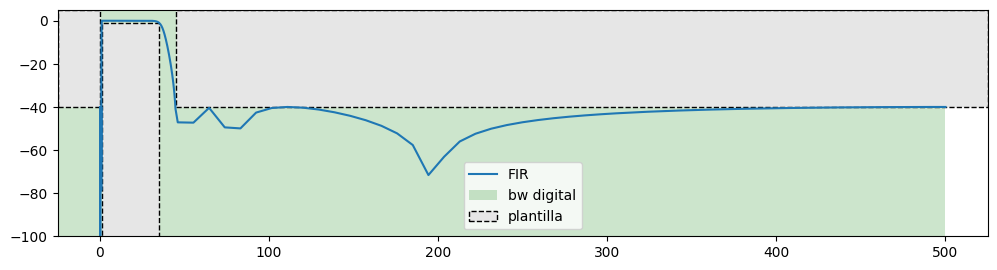

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\3703784642.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\3703784642.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\3703784642.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


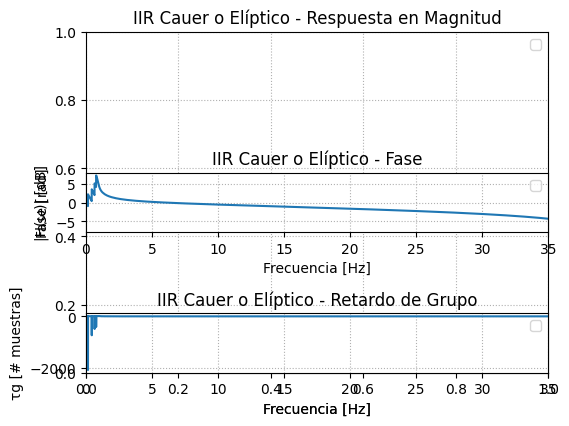

In [6]:
#%% CHEBYSHEV TIPO 2
taps_cheby2 = sos_f_cheby2.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega_cheby2, resp_freq_cheby2 = sig.freqz_sos(sos_f_cheby2, worN = ww, fs = fs)
phase_cheby2 = np.unwrap(np.angle(resp_freq_cheby2))
gd_cheby2 = -np.diff(phase_cheby2) / np.diff(ww)
gd_cheby2 = np.append(gd_cheby2[0], gd_cheby2)

# GRAFICOS

# MODULO
plt.figure(figsize=(12,10))

plt.subplot(3,1,1)
plt.plot(omega_cheby2, 20*np.log10(abs(resp_freq_cheby2)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('IIR Cauer o Elíptico - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
# plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(omega_cheby2, phase_cheby2)
plt.title('IIR Cauer o Elíptico - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(ww, gd_cheby2)
plt.title('IIR Cauer o Elíptico - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\Gerog\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


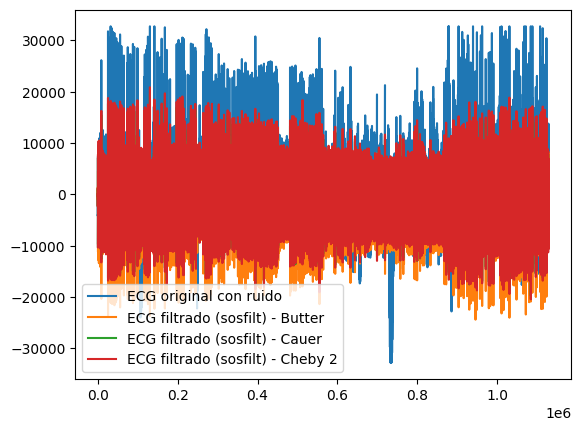

In [7]:
#%% Como implementamos el filtro? 
# Para usarlo necesitamos la señal 
import scipy.io as sio

fs_ecg = 1000 # Hz

# ECG con ruido 
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']. flatten()

# N = len(ecg_one_lead) 

# Limito la energia al ancho de banda para ver bien la señal electrocardiografica 
# Usamos la funcion de scipy.signal --> sosfilt --> va a tener limitaciones 

ECG_f_butter = sig.sosfilt(sos_f_butter, ecg_one_lead)
ECG_f_cauer = sig.sosfilt(sos_f_cauer, ecg_one_lead)
ECG_f_cheby2 = sig.sosfilt(sos_f_cheby2, ecg_one_lead)

plt.figure()
plt.plot(ecg_one_lead, label = 'ECG original con ruido')
plt.plot(ECG_f_butter, label = 'ECG filtrado (sosfilt) - Butter')
plt.plot(ECG_f_cauer, label = 'ECG filtrado (sosfilt) - Cauer')
plt.plot(ECG_f_cheby2, label = 'ECG filtrado (sosfilt) - Cheby 2')
plt.legend()
plt.show()

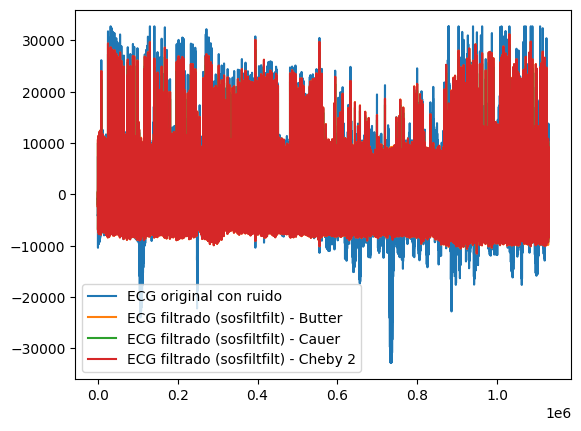

In [8]:
#%% Vamos a usar sosfiltfilt
# Hace un backward - fordward 
# Es un filtrado bidireccional, y lo que asume es como que pasas dos veces por la respuesta de modulo 
# Es decir, voy a tener 2alfa max de ripple, y 2alfa min de atenuacion 
# Y en dB es como tener el doble de dB
# El efecto de invertir en tiempo es util para el retardo de fase? Neutraliza la fase, sincroniza temporalmente la señal original con la filtrada

sos_ff_butter = sig.iirdesign(wp, ws, gpass / 2, gstop / 2, analog = False, ftype = 'butter', output = 'sos', fs = fs)
sos_ff_cauer = sig.iirdesign(wp, ws, gpass / 2, gstop / 2, analog = False, ftype = 'cauer', output = 'sos', fs = fs)
sos_ff_cheby2 = sig.iirdesign(wp, ws, gpass / 2, gstop / 2, analog = False, ftype = 'cheby2', output = 'sos', fs = fs)

taps = sos_ff_butter.shape[0] * 2 # El por dos es porque son todos de segundo orden 
omega, resp_freq = sig.freqz_sos(sos_ff_butter, worN = ww, fs = fs)
phase = np.unwrap(np.angle(resp_freq))

ECG_ff_butter = sig.sosfiltfilt(sos_ff_butter, ecg_one_lead)
ECG_ff_cauer = sig.sosfiltfilt(sos_ff_cauer, ecg_one_lead)
ECG_ff_cheby2 = sig.sosfiltfilt(sos_ff_cheby2, ecg_one_lead)

plt.figure()
plt.plot(ecg_one_lead, label = 'ECG original con ruido')
plt.plot(ECG_ff_butter, label = 'ECG filtrado (sosfiltfilt) - Butter')
plt.plot(ECG_ff_cauer, label = 'ECG filtrado (sosfiltfilt) - Cauer')
plt.plot(ECG_ff_cheby2, label = 'ECG filtrado (sosfiltfilt) - Cheby 2')
plt.legend()
plt.show()

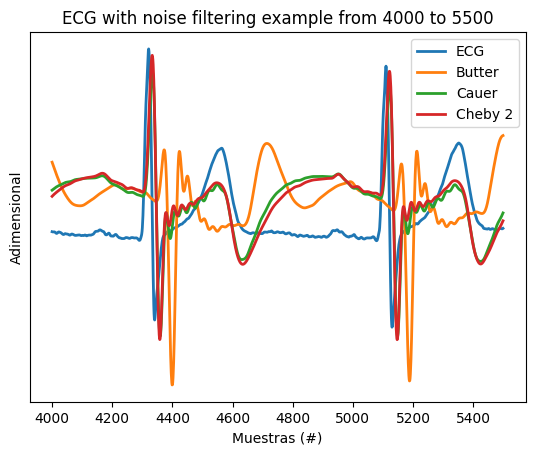

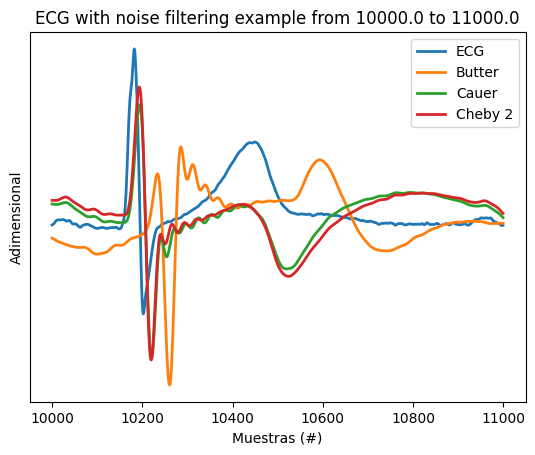

In [9]:
#%% Regiones de interés con ruido
 
N = len(ecg_one_lead) 
cant_muestras = N

regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butter[zoom_region], label='Butter', linewidth=2)
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer', linewidth=2)
    plt.plot(zoom_region, ECG_f_cheby2[zoom_region], label='Cheby 2', linewidth=2)
   
    plt.title('ECG with noise filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

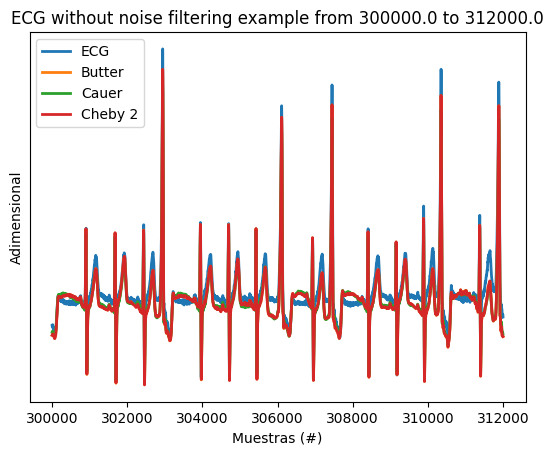

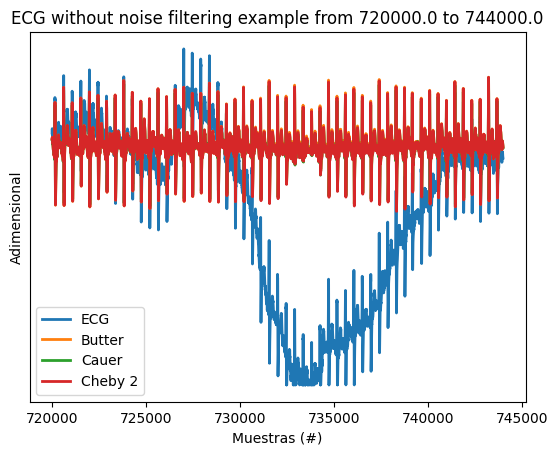

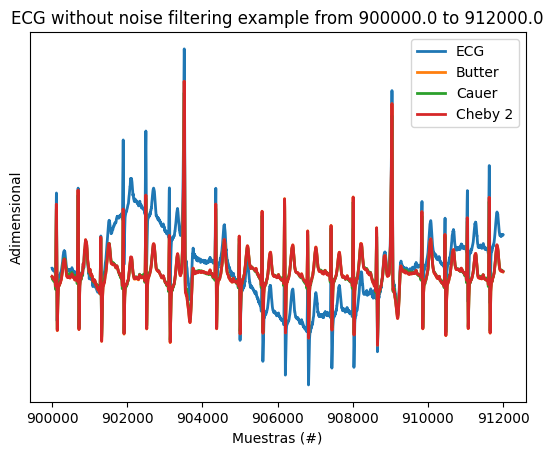

In [10]:
#%% Regiones de interés sin ruido
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_ff_butter[zoom_region], label='Butter', linewidth=2)
    plt.plot(zoom_region, ECG_ff_cauer[zoom_region], label='Cauer', linewidth=2)
    plt.plot(zoom_region, ECG_ff_cheby2[zoom_region], label='Cheby 2', linewidth=2)
   
    plt.title('ECG without noise filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

# Diseño de filtros FIR 

# firwin o firwin2 --> usa ventana
# La uno solo me deja hacer tipo 1 y 2, la firwin2 me deja usar todos 
# firls --> cuadrados minimos
# remez --> diseño de filtros en base al metodo de park Mc --> optimizacion
# Los ultimos dos son "mejores", atenuan mas rapido

# Frecuencia 
fs = 1000 # Hz

# ww es para el WorN
ww = np.concatenate([np.logspace(start = -2, stop = 0.1, num = 500),
                np.linspace(start = 1.26, stop = 35, num = 200),
                np.logspace(start = 1.55, stop = 1.65, num = 300),
                np.linspace(start = 46, stop = fs//2, num = 50)])
ww = np.sort(ww)

# Plantilla de diseño del filtro 
wp1 = 1 # Hz
wp2 = 35 # Hz --> 30 es aprox el ancho de banda que nos dio en la TS5
ws1 = .1 # Hz 
ws2 = 45 # Hz
gpass = 1 # dB
gstop = 40 # dB 

wp = (wp1, wp2) # Comienzo y fin de la banda de paso
ws = (ws1, ws2) # Comienzo y fin de la banda de stop


# HACK para la plantilla de diseño
wp1_hack = 1 # Hz
wp2_hack = 35 # Hz --> 30 es aprox el ancho de banda que nos dio en la TS5
ws1_hack = .3 # Hz 
ws2_hack = 35.4 # Hz
gpass_hack = 1 # dB
gstop_hack = 40 # dB 

wp_hack = (wp1_hack, wp2_hack) # Comienzo y fin de la banda de paso
ws_hack = (ws1_hack, ws2_hack) # Comienzo y fin de la banda de stop

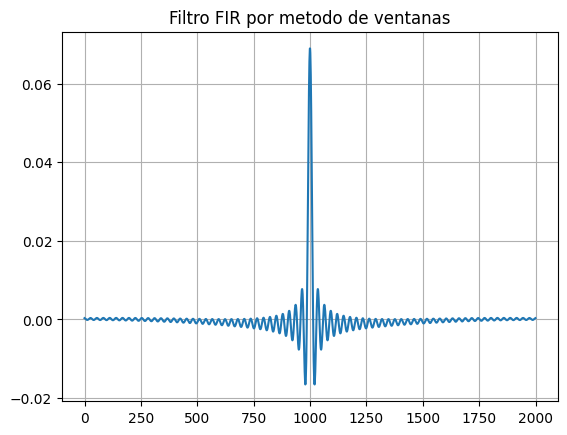

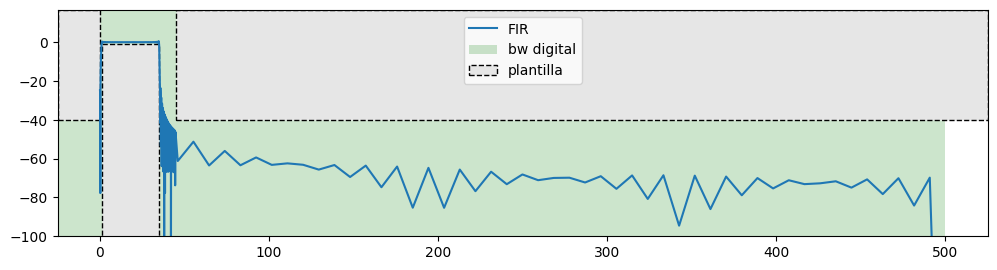

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1176017671.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1176017671.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1176017671.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


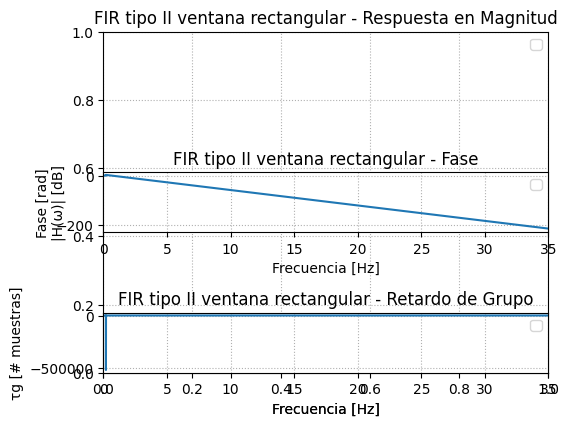

In [11]:
#%% FIRWIN2
# Me devuelve los coeficientes 'b' (los coeficientes 'a' son cero menos el 'a0' que vale 1)
# Como no hay coeficientes 'ai', no hay recurcion, no hay problemas numericos exagerados --> puedo implementar sos

numtaps = 2000
# Si tengo 8000 taps --> en tiempo tengo: N = 8000 y la distancia entre muestras es N*Ts = N/fs = 8segundos

freq = np.array([0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs//2]) # Tinee que ir siempre para arriba
# El fs/2 es Nyquist y es porque no esta normalizado

# gain = 10**(((-1)*np.array([gstop, gstop, gpass, gpass, gstop, gstop])/20)) # Es la respuesta deseada
gain = np.array([0, 0, 1, 1, 0, 0])

# if numtaps % 2 == 0: # '%' es el resto de la division
#     gain[-1] = 0 # Fuerzo para que termine en cero, que en Nyquist haya un cero --> esto es porque al tener un filtro de tipo II (numtaps 30), tengo un cero topologico en Nyquist

# FIR con ventana rectangular
fir_win = sig.firwin2(numtaps, freq, gain, nfreqs = 2**14, window = 'boxcar', fs = fs)
retardo = (numtaps - 1)//2

plt.figure()
plt.title('Filtro FIR por metodo de ventanas')
plt.plot(fir_win)
plt.grid()
plt.show()

# Respuesta en frecuencia
w_fir, h_fir = sig.freqz(fir_win, worN = ww, fs = fs)
fase_fir = np.unwrap(np.angle(h_fir))
gd_fir = -np.diff(fase_fir) / np.diff(w_fir/fs*np.pi)

ceros, polos, k = sig.tf2zpk(fir_win, a = 1)

# GRAFICOS

# MODULO
plt.figure(figsize=(12,10))

plt.subplot(3,1,1)
plt.plot(w_fir, 20*np.log10(abs(h_fir)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('FIR tipo II ventana rectangular - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
#plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(w_fir, fase_fir)
plt.title('FIR tipo II ventana rectangular - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(w_fir[1:], gd_fir)
plt.title('FIR tipo II ventana rectangular - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

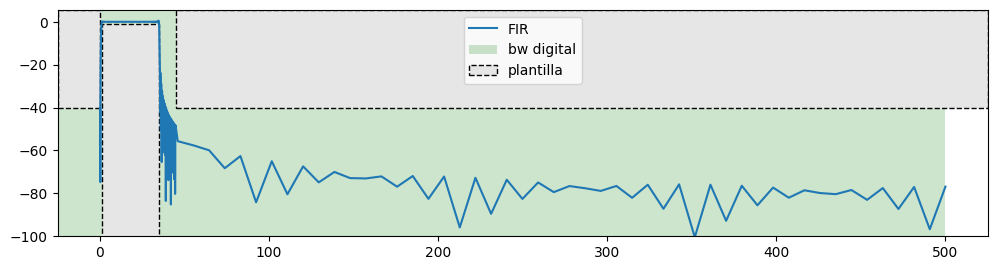

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2578866169.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2578866169.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2578866169.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


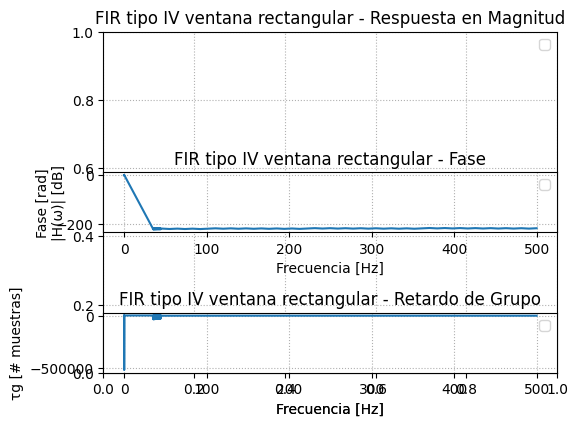

In [12]:
#%% FIR ANTISIMETRICO con ventanas
fir_win_ant = sig.firwin2(numtaps, freq, gain, nfreqs = 2**14, window = 'boxcar', fs = fs, antisymmetric = True)

# Respuesta en frecuencia
w_fir_ant, h_fir_ant = sig.freqz(fir_win_ant, worN = ww, fs = fs)
fase_fir_ant = np.unwrap(np.angle(h_fir_ant))
gd_fir_ant = -np.diff(fase_fir_ant) / np.diff(w_fir_ant/fs*np.pi)

# GRAFICOS
plt.figure(figsize=(12,10))

# MODULO
plt.subplot(3,1,1)
plt.plot(w_fir_ant, 20*np.log10(abs(h_fir_ant)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('FIR tipo IV ventana rectangular - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
#plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(w_fir_ant, fase_fir_ant)
plt.title('FIR tipo IV ventana rectangular - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
# plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(w_fir_ant[1:], gd_fir_ant)
plt.title('FIR tipo IV ventana rectangular - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
#plt.xlim(0, 65)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

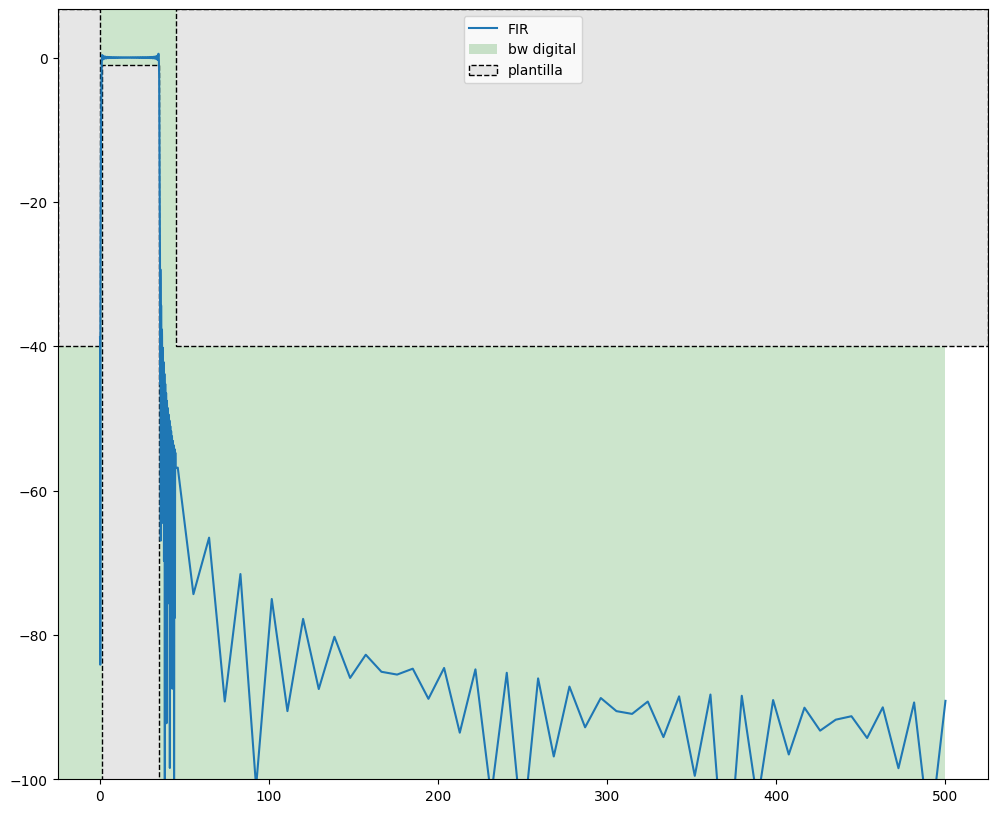

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1800957355.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


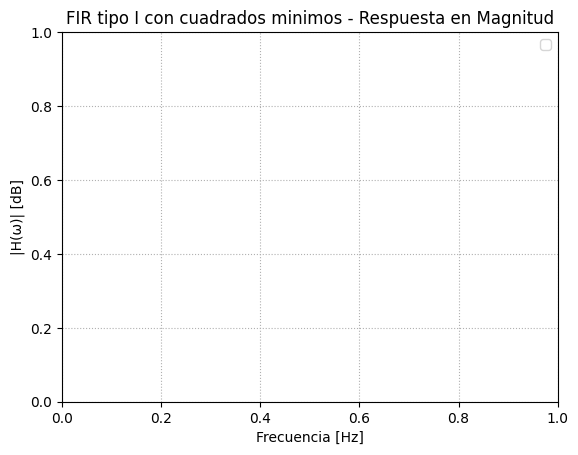

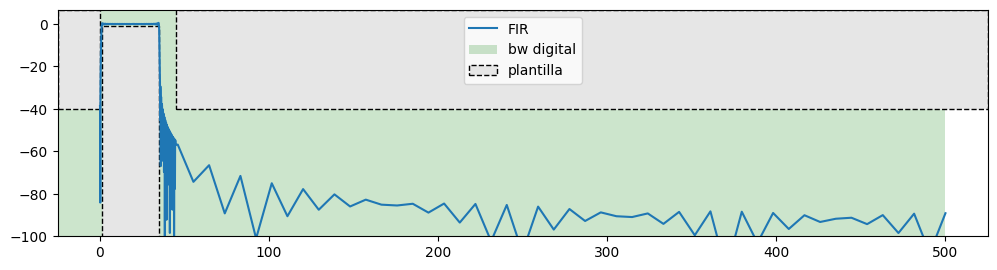

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1800957355.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1800957355.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\1800957355.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


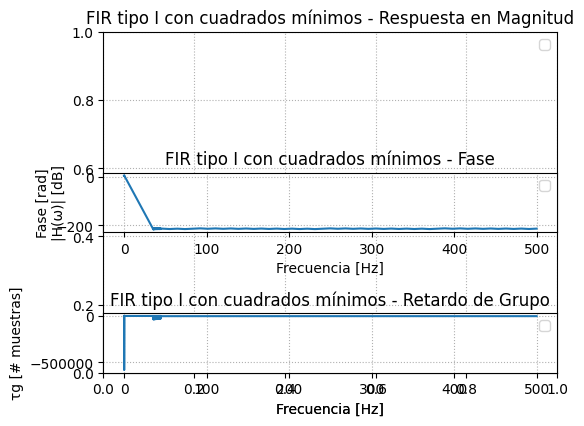

In [13]:
#%% FIR SIMETRICO con CUADRADOS MINIMOS 
numtaps = 2001
# Si tengo 8000 taps --> en tiempo tengo: N = 8000 y la distancia entre muestras es N*Ts = N/fs = 8segundos

freq = np.array([0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs//2]) # Tinee que ir siempre para arriba
# El fs/2 es Nyquist y es porque no esta normalizado

# Ganancia, banda y peso 
band = [0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs/2]
gain  = [0, 0, 1, 1, 0, 0]
weight = [10, 1, 5]

# FIR con cuadrados minimos
fir_ls = sig.firls(numtaps, band, gain, weight = weight, fs = fs)

# Respuesta en frecuencia
ls_fir, h_fir_ls = sig.freqz(fir_ls, worN = ww, fs = fs)
fase_fir_ls = np.unwrap(np.angle(h_fir_ls))
gd_fir_ls = -np.diff(fase_fir_ls) / np.diff(ls_fir/fs*np.pi)

# GRAFICOS
# MODULO
plt.figure(figsize=(12,10))

plt.plot(ls_fir, 20*np.log10(abs(h_fir_ls)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('FIR tipo I con cuadrados minimos - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
#plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.show()

# GRAFICOS
plt.figure(figsize=(12,10))

# MODULO
plt.subplot(3,1,1)
plt.plot(ls_fir, 20*np.log10(abs(h_fir_ls)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('FIR tipo I con cuadrados mínimos - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
#plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(ls_fir, fase_fir_ls)
plt.title('FIR tipo I con cuadrados mínimos - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
# plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(ls_fir[1:], gd_fir_ls)
plt.title('FIR tipo I con cuadrados mínimos - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
#plt.xlim(0, 65)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

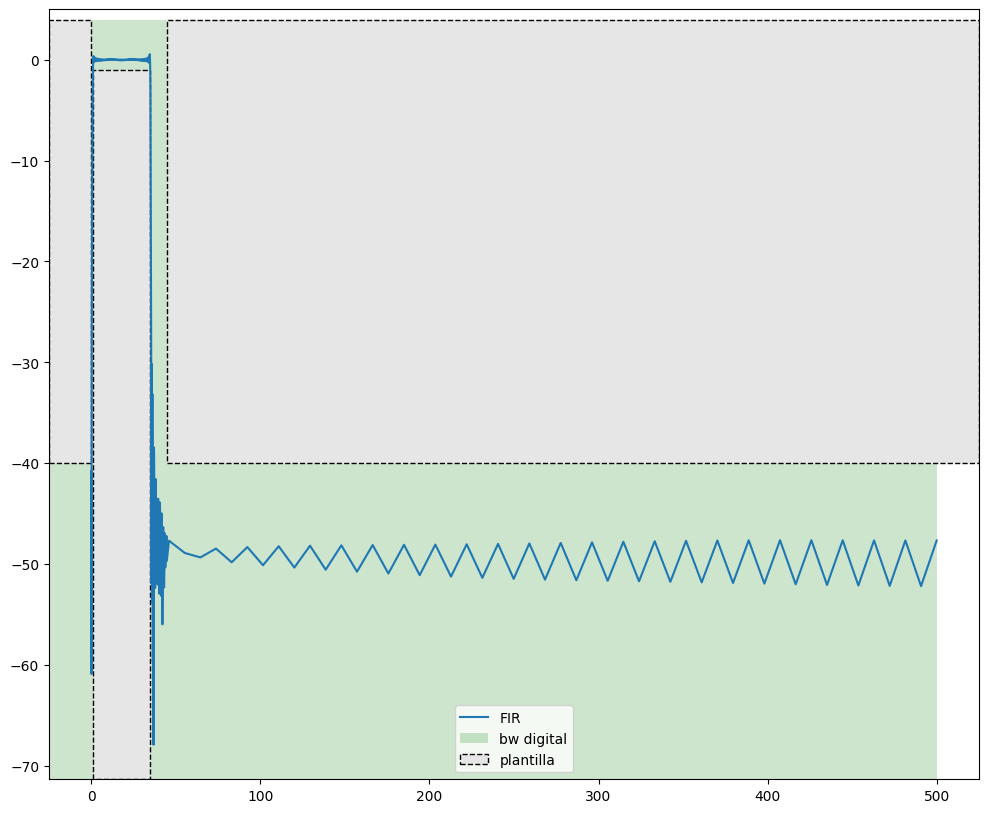

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2384938430.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


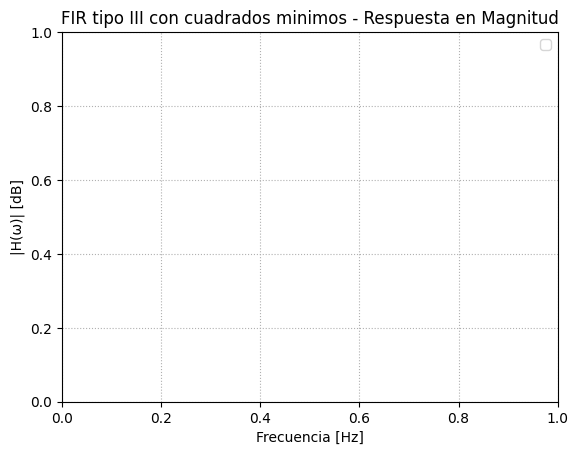

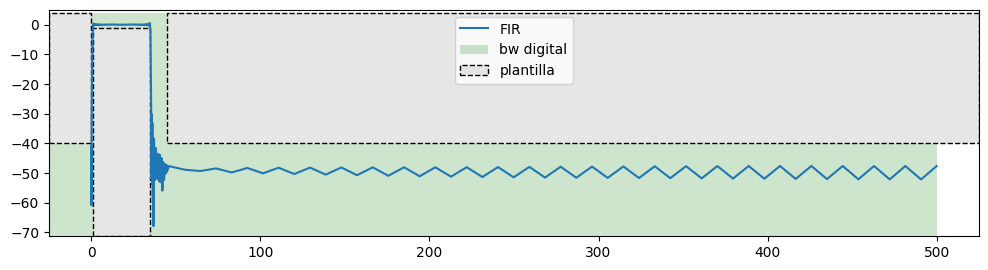

C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2384938430.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2384938430.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Gerog\AppData\Local\Temp\ipykernel_13496\2384938430.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


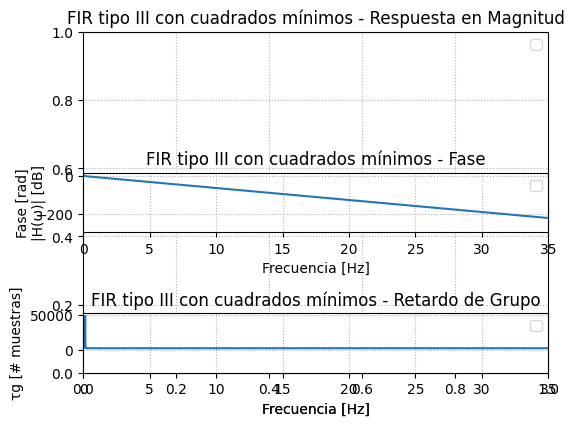

In [14]:
#%% FIR ANTISIMETRICO con CUADRADOS MINIMOS

# Eje de simetria
numtaps = 1835
M = numtaps - 1

# Copia para modificar
fir_antisym = fir_ls.copy() 

# Forzar coeficiente central a cero si numtaps es impar
if numtaps % 2 == 1:
    fir_antisym[M//2] = 0.0

# De la mitad en adelante le cambio el signo 
fir_antisym[M:numtaps] = fir_antisym[M:numtaps] * (-1)

# Respuesta en frecuencia FIR antisimetrico 
ls_fir_ant, h_fir_ls_ant = sig.freqz(fir_antisym, worN = ww, fs = fs)
fase_fir_ls_ant = np.unwrap(np.angle(h_fir_ls_ant))
gd_fir_ls_ant = -np.diff(fase_fir_ls_ant) / np.diff(ls_fir_ant/fs*np.pi)

# GRAFICOS
# MODULO
plt.figure(figsize=(12,10))

plt.plot(ls_fir_ant, 20*np.log10(abs(h_fir_ls_ant)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('FIR tipo III con cuadrados minimos - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
#plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.show()

# GRAFICOS
plt.figure(figsize=(12,10))

# MODULO
plt.subplot(3,1,1)
plt.plot(ls_fir_ant, 20*np.log10(abs(h_fir_ls_ant)), label="FIR")
plot_plantilla('bandpass', wp, gpass, ws, gstop, fs)
plt.title('FIR tipo III con cuadrados mínimos - Respuesta en Magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(ω)| [dB]')
#plt.xlim(0, 500)
plt.grid(True, which='both', ls=':')
plt.legend()

# FASE
plt.subplot(3,1,2)
plt.plot(ls_fir_ant, fase_fir_ls_ant)
plt.title('FIR tipo III con cuadrados mínimos - Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

# RETARDO
plt.subplot(3,1,3)
plt.plot(ls_fir_ant[1:], gd_fir_ls_ant)
plt.title('FIR tipo III con cuadrados mínimos - Retardo de Grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('τg [# muestras]')
plt.xlim(0, 35)
plt.grid(True, which='both', ls=':')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
#%% Procesar el ECG
import scipy.io as sio

fs_ecg = 1000 # Hz

# ECG con ruido 
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']. flatten()

ecg_firwin = sig.filtfilt(fir_win_ant, 1., ecg_one_lead)
ecg_firls = sig.filtfilt(fir_antisym, 1., ecg_one_lead)

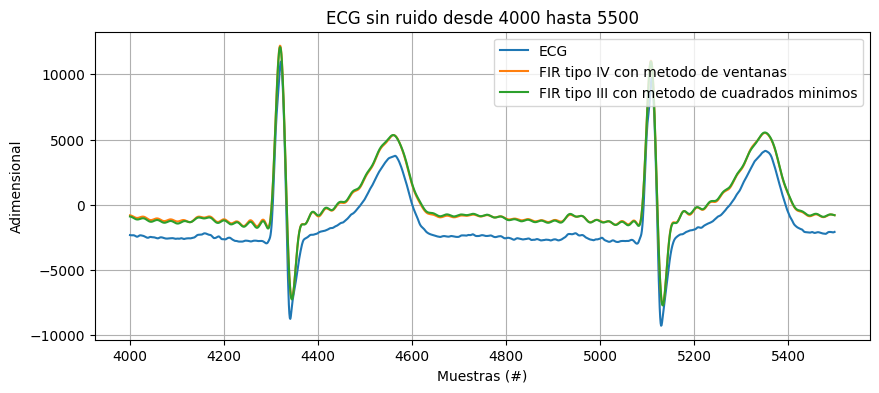

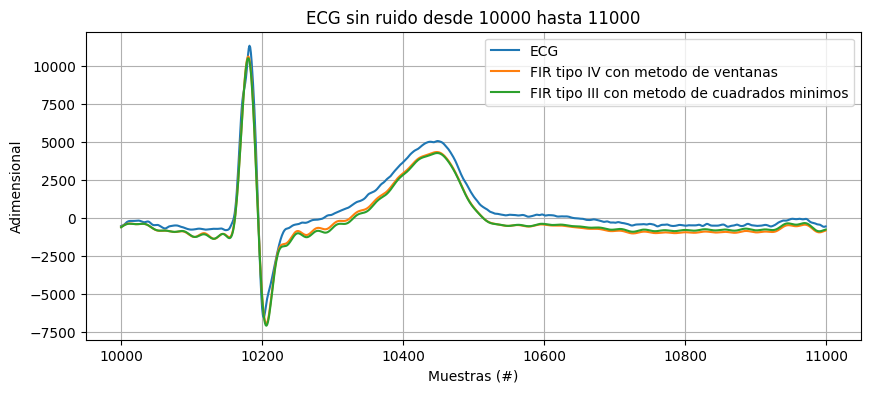

In [16]:
# %% GRAFICOS — ZONAS SIN RUIDO

regiones_sin_ruido = [
    [4000, 5500],
    [10000, 11000]
]

for r in regiones_sin_ruido:
    a,b = r
    t = np.arange(a,b)

    plt.figure(figsize=(10,4))
    plt.plot(t, ecg_one_lead[t], label="ECG")
    plt.plot(t, ecg_firwin[t], label="FIR tipo IV con metodo de ventanas")
    plt.plot(t, ecg_firls[t], label="FIR tipo III con metodo de cuadrados minimos")
    plt.title('ECG sin ruido desde ' + str(r[0]) + ' hasta ' + str(r[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.legend()
    plt.grid()

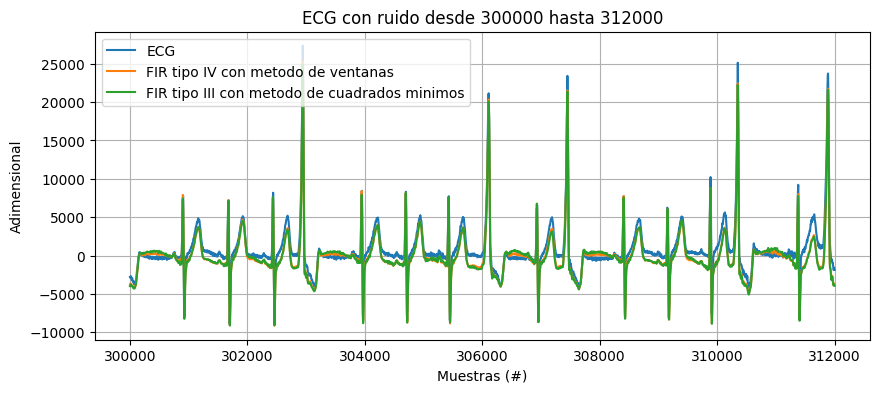

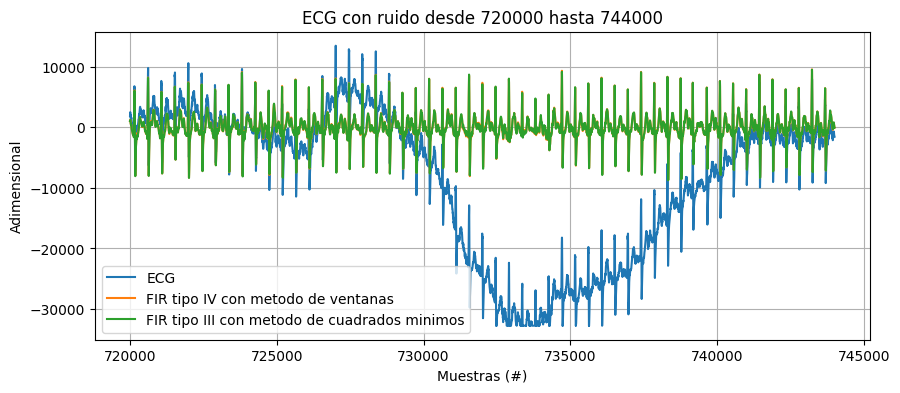

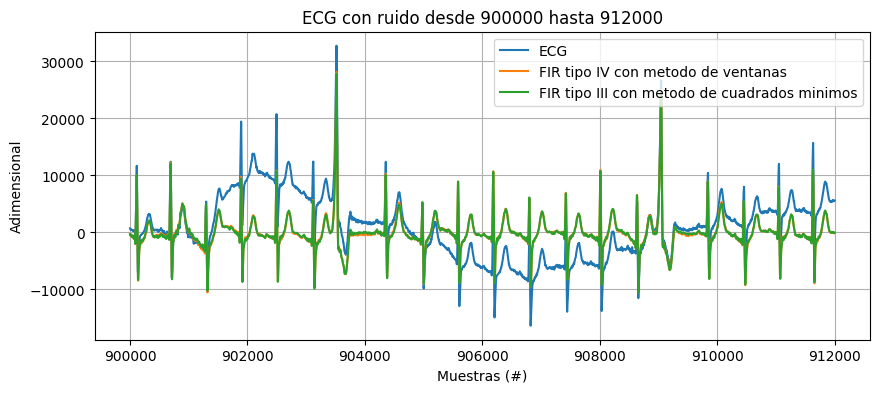

In [17]:
# %% GRAFICOS — ZONAS CON RUIDO

regiones_ruidosas = [
    (np.array([5, 5.2])*60*fs).astype(int),
    (np.array([12, 12.4])*60*fs).astype(int),
    (np.array([15, 15.2])*60*fs).astype(int)
]

for r in regiones_ruidosas:
    a,b = r
    t = np.arange(a,b)

    plt.figure(figsize=(10,4))
    plt.plot(t, ecg_one_lead[t], label="ECG")
    plt.plot(t, ecg_firwin[t], label="FIR tipo IV con metodo de ventanas")
    plt.plot(t, ecg_firls[t], label="FIR tipo III con metodo de cuadrados minimos")
    plt.title('ECG con ruido desde ' + str(r[0]) + ' hasta ' + str(r[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.legend()
    plt.grid()
